## IMPORTS

In [1]:
# Importación de módulos estándar
import os
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Importación de módulos personalizados
from src.models import InceptionMNISTModel
from src.utils import load_data, evaluate_model
from src.cro import CoralReefOptimization
from src.visualization import visualize_inception_module

# Importación de módulos para visualización y utilidades adicionales
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Configuración del dispositivo (CPU o GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")


Usando dispositivo: cuda


In [ ]:
# Cargar datos de entrenamiento, validación y prueba
train_loader, val_loader, test_loader = load_data(shuffle_dataset=True)


In [ ]:
# Definición de los parámetros de las ramas del módulo Inception
branches_params = [
    {
        'depth': 2,
        'filter_sizes': [(3, 3), (5, 5)],
        'filter_channels': [32, 64],
        'use_pooling': False
    },
    {
        'depth': 3,
        'filter_sizes': [(1, 1), (3, 3), (1, 1)],
        'filter_channels': [16, 32, 16],
        'use_pooling': True
    },
    {
        'depth': 1,
        'filter_sizes': [(7, 7)],
        'filter_channels': [32],
        'use_pooling': False
    }
]

# Parámetros del modelo
model_params = {
    'branches_params': branches_params
}

# Crear una instancia del modelo
model = InceptionMNISTModel(model_params).to(device)


In [ ]:
# Visualizar y guardar la arquitectura del modelo
visualization_dir = 'analysis_visualizations'
os.makedirs(visualization_dir, exist_ok=True)
visualize_inception_module(model, generation=0, idx='custom_model', output_dir=visualization_dir)


In [ ]:
def train_model(model, device, train_loader, optimizer, criterion, num_epochs=5):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}")


In [ ]:
# Definir el criterio de pérdida y el optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenar el modelo
train_model(model, device, train_loader, optimizer, criterion, num_epochs=5)


In [ ]:
# Evaluar el modelo en el conjunto de validación
fitness_val, accuracy_val, avg_loss_val = evaluate_model(model, val_loader, device)
print(f"\nEvaluación en el conjunto de validación:")
print(f"Fitness: {fitness_val:.2f}, Precisión: {accuracy_val:.2f}%, Pérdida promedio: {avg_loss_val:.4f}")

# Evaluar el modelo en el conjunto de prueba
fitness_test, accuracy_test, avg_loss_test = evaluate_model(model, test_loader, device)
print(f"\nEvaluación en el conjunto de prueba:")
print(f"Fitness: {fitness_test:.2f}, Precisión: {accuracy_test:.2f}%, Pérdida promedio: {avg_loss_test:.4f}")


In [ ]:
def fitness_function(model_params):
    try:
        model = InceptionMNISTModel(model_params).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()
        model.train()
        num_batches = 100  # Número de lotes para entrenar (ajustar según sea necesario)
        for batch_idx, (images, labels) in enumerate(train_loader):
            if batch_idx >= num_batches:
                break
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        # Evaluar en el conjunto de validación
        fitness, _, _ = evaluate_model(model, val_loader, device)
        return fitness
    except Exception as e:
        print(f"Evaluación del modelo fallida: {e}")
        return 0  # Peor aptitud posible


In [ ]:
# Parámetros del CRO
cro = CoralReefOptimization(
    reef_size=(4, 4),
    rho_0=0.6,
    Fb=0.98,
    Fa=0.05,
    Pd=0.05,
    kappa=3,
    mutation_rate=0.2,
    fitness_function=fitness_function,
    max_generations=10,  # Reducido para demostración rápida
    max_no_improve=5
)


In [ ]:
# Ejecutar el algoritmo CRO
cro.run()


In [ ]:
# Mostrar el historial de fitness
print("\nHistorial de fitness:")
for gen, fitness in enumerate(cro.fitness_history, 1):
    print(f"Generación {gen}: Fitness = {fitness:.2f}")


In [ ]:
# Graficar la evolución del fitness
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cro.fitness_history) + 1), cro.fitness_history, marker='o')
plt.title('Evolución del Fitness a lo Largo de las Generaciones')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.grid(True)
plt.show()


In [ ]:
from IPython.display import Image

best_coral_image = os.path.join('visualizations', 'best_coral', f'generation_{cro.generation}_best_coral.png')

if os.path.exists(best_coral_image):
    print("Mejor arquitectura encontrada:")
    display(Image(filename=best_coral_image))
else:
    print("No se encontró la imagen de la mejor arquitectura.")


In [ ]:
# Obtener los parámetros del mejor modelo
best_model_params = cro.best_coral['solution']
best_model = InceptionMNISTModel(best_model_params).to(device)

# Entrenar el mejor modelo completo
optimizer = optim.Adam(best_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
epochs = 5  # Ajustar según sea necesario
train_model(best_model, device, train_loader, optimizer, criterion, num_epochs=epochs)

# Evaluar en el conjunto de prueba
fitness_test, accuracy_test, avg_loss_test = evaluate_model(best_model, test_loader, device)
print(f"\nEvaluación del mejor modelo en el conjunto de prueba:")
print(f"Fitness: {fitness_test:.2f}, Precisión: {accuracy_test:.2f}%, Pérdida promedio: {avg_loss_test:.4f}")


In [ ]:
# Datos de resultados
results = {
    'reef_size': cro.N * cro.M,
    'rho_0': cro.rho_0,
    'Fb': cro.Fb,
    'Fa': cro.Fa,
    'Pd': cro.Pd,
    'kappa': cro.kappa,
    'mutation_rate': cro.mutation_rate,
    'max_generations': cro.max_generations,
    'best_fitness': cro.best_coral['fitness'],
    'test_accuracy': accuracy_test,
    'best_model_params': best_model_params
}

# Guardar resultados en CSV
output_file = 'cro_results.csv'

def save_results_to_csv(results, filename):
    import csv
    fieldnames = list(results.keys())
    file_exists = os.path.isfile(filename)

    with open(filename, mode='a', newline='') as csv_file:
        writer = csv.DictWriter(csv_file, fieldnames=fieldnames)

        if not file_exists:
            writer.writeheader()  # Escribir encabezados si el archivo es nuevo

        writer.writerow(results)

save_results_to_csv(results, output_file)
print(f"\nResultados guardados en {output_file}")


## TESTING

In [ ]:
from src.utils import load_data, evaluate_model
from src.models import InceptionModule, InceptionMNISTModel
from src.cro import CoralReefOptimization
from src.visualization import visualize_inception_module

import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

### utils

In [ ]:
# load dataset
train_loader, val_loader, test_loader = load_data(shuffle_dataset=True)

In [ ]:
# show dataset sizes
print(f"Training dataset size: {len(train_loader.dataset)}")
print(f"Validation dataset size: {len(val_loader.dataset)}")
print(f"Test dataset size: {len(test_loader.dataset)}")

# example of training data
images, labels = next(iter(train_loader))
print(f"Images shape: {images.shape}, Labels shape: {labels.shape}")

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
# one example image
image = images[0].squeeze().numpy()
plt.imshow(image, cmap='gray')
plt.axis('off') # hide axes
plt.show()

# print label for the image
label = labels[0]
print(f"Label: {label}")

### cro

In [ ]:
def fitness_function(model_params):
  try:
      model = InceptionMNISTModel(model_params).to(device)
      optimizer = optim.Adam(model.parameters(), lr=0.001)
      criterion = nn.CrossEntropyLoss()
      model.train()
      num_batches = 100  # Número de lotes para entrenar (ajustar según sea necesario)
      for batch_idx, (images, labels) in enumerate(train_loader):
          if batch_idx >= num_batches:
              break
          images, labels = images.to(device), labels.to(device)
          optimizer.zero_grad()
          outputs = model(images)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()
      # Evaluar en el conjunto de validación
      fitness, accuracy, _ = evaluate_model(model, val_loader, device)
      return fitness
  except Exception as e:
      print(f"Evaluación del modelo fallida: {e}")
      return 0  # Peor aptitud posible

In [ ]:
# create a coral reef instance
reef = CoralReefOptimization(
    reef_size=(2, 2),
    rho_0=0.6,
    Fb=0.98,
    Fa=0.05,
    Pa=0.001,
    Fd=0.05,
    Pd=0.01,
    kappa=3,
    mutation_rate=0.2,
    fitness_function=fitness_function,
    max_generations=2,  # Reducido para demostración rápida
    max_no_improve=5
)

In [ ]:
reef.run()

### models

In [ ]:
# create a custom instance of the InceptionModule
branches_params = [
    {
        'depth': 2,
        'filter_sizes': [(3, 3), (5, 5)],
        'filter_channels': [32, 64],
        'use_pooling': False
    },
    {
        'depth': 3,
        'filter_sizes': [(1, 1), (3, 3), (1, 1)],
        'filter_channels': [16, 32, 16],
        'use_pooling': True
    },
    {
        'depth': 1,
        'filter_sizes': [(7, 7)],
        'filter_channels': [32],
        'use_pooling': False
    }
]

inception_module = InceptionModule(in_channels=3,
                                   branches_params=branches_params
)

In [ ]:
# summary of the InceptionModule
print(inception_module)

In [ ]:
# create inception mnist model, from the best coral solution
inception_model = InceptionMNISTModel(reef.best_coral['solution']).to(device)

### visualization

In [ ]:
from src.visualization import visualize_inception_module

# visualize the InceptionModule
visualize_inception_module(inception_model, 
                           generation=0, 
                           idx='custom_inception_module',
                           output_dir='analysis_visualizations')

In [ ]:
from IPython.display import Image

# display previosuly saved image
Image(filename='analysis_visualizations/custom_model_inception.png')

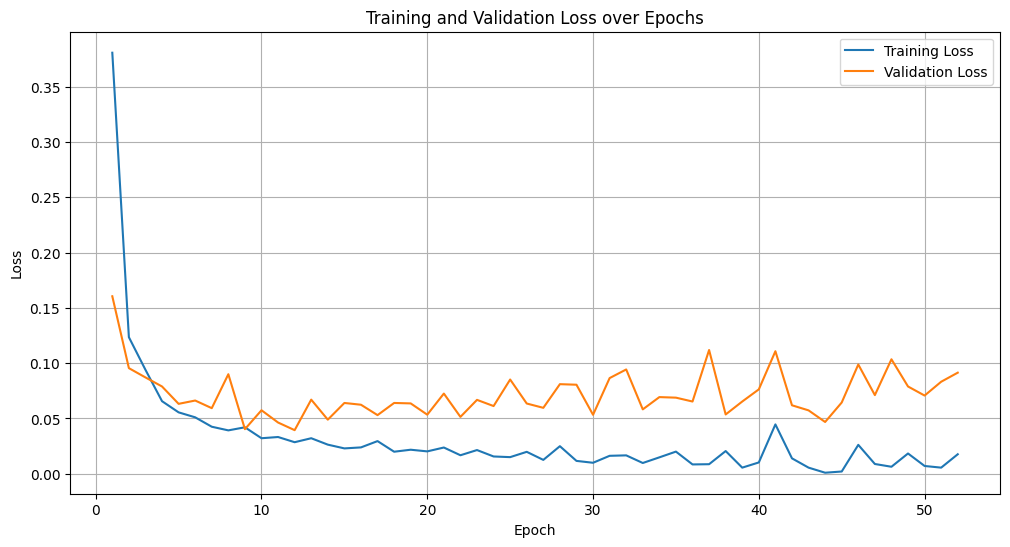

In [1]:
import matplotlib.pyplot as plt

# Data
epochs = list(range(1, 53))
train_loss = [0.3808, 0.1235, 0.0940, 0.0656, 0.0555, 0.0510, 0.0425, 0.0392, 0.0420, 0.0321,
              0.0332, 0.0285, 0.0321, 0.0263, 0.0229, 0.0238, 0.0295, 0.0199, 0.0217, 0.0202,
              0.0237, 0.0167, 0.0214, 0.0156, 0.0150, 0.0198, 0.0125, 0.0249, 0.0116, 0.0099,
              0.0162, 0.0166, 0.0097, 0.0148, 0.0200, 0.0084, 0.0086, 0.0205, 0.0055, 0.0102,
              0.0446, 0.0139, 0.0055, 0.0009, 0.0020, 0.0261, 0.0088, 0.0063, 0.0183, 0.0070,
              0.0055, 0.0176]

val_loss = [0.1605, 0.0955, 0.0871, 0.0789, 0.0632, 0.0662, 0.0593, 0.0900, 0.0403, 0.0574,
            0.0463, 0.0394, 0.0670, 0.0489, 0.0640, 0.0624, 0.0530, 0.0640, 0.0636, 0.0534,
            0.0725, 0.0514, 0.0668, 0.0612, 0.0852, 0.0635, 0.0596, 0.0810, 0.0805, 0.0533,
            0.0865, 0.0943, 0.0582, 0.0693, 0.0688, 0.0653, 0.1119, 0.0536, 0.0653, 0.0763,
            0.1108, 0.0619, 0.0573, 0.0468, 0.0644, 0.0988, 0.0711, 0.1035, 0.0789, 0.0707,
            0.0832, 0.0914]

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plot_filename = 'training_curve.png'
plt.savefig(plot_filename)

In [ ]:
    plt.figure(figsize=(10, 6))
    plt.plot(generations, cro.fitness_history, label='Mejor Fitness')
    plt.plot(generations, cro.avg_fitness_history, label='Fitness Promedio')
    plt.xlabel('Generación')
    plt.ylabel('Fitness')
    plt.title('Evolución del Fitness a lo Largo de las Generaciones')
    plt.legend()
    plt.grid(True)

    # Guardar la gráfica
    plot_filename = 'fitness_convergence.png'
    plt.savefig(plot_filename)